<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana4/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("CORREÇÃO DO LAB 1: O FALSIFICADOR DIGITAL (BINÁRIO)")
print("="*60)

# 1. IMPORTAÇÃO DOS DADOS
url_banknote = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
df = pd.read_csv(url_banknote, header=None)


CORREÇÃO DO LAB 1: O FALSIFICADOR DIGITAL (BINÁRIO)


In [94]:
df.describe()

,0,1,2,3,4
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [95]:
X_dados = df.iloc[:, 0:4].values
Y_dados = df.iloc[:, 4].values

In [96]:
df.shape

(1372, 5)

In [97]:
np.unique(Y_dados, return_counts=True)

(array([0, 1]), array([762, 610]))

In [98]:
len(X_dados)

1372

In [99]:
X_temp, X_test, Y_temp, Y_test = train_test_split(X_dados, Y_dados, test_size=0.25, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.25, random_state=42)

In [101]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [102]:
modelo_banco = Sequential(name="Detetive_Digital_V1")
modelo_banco.add(Input(shape=(4,), name="Input_4_Assinaturas"))
modelo_banco.add(Dense(12, activation='relu', name="Oculta_1"))
modelo_banco.add(Dense(8, activation='relu', name="Oculta_2"))
modelo_banco.add(Dense(1, activation='sigmoid', name="Saida_Binaria"))


In [103]:
modelo_banco.summary()

Model: "Detetive_Digital_V1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Oculta_1 (Dense)                │ (None, 12)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Binaria (Dense)           │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173 (692.00 B)

 Trainable params: 173 (692.00 B)

 Non-trainable params: 0 (0.00 B)

In [104]:
modelo_banco.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [105]:
freio_emergencia = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, min_delta=0.001
)

In [106]:
historico = modelo_banco.fit(
    X_train_scaled, Y_train,
    validation_data=(X_val_scaled, Y_val),
    epochs=80, batch_size=12,
    callbacks=[freio_emergencia], verbose=1
)

Epoch 1/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9339 - loss: 0.5507 - val_accuracy: 0.9806 - val_loss: 0.4711
Epoch 2/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9559 - loss: 0.3977 - val_accuracy: 0.9845 - val_loss: 0.3019
Epoch 3/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9650 - loss: 0.2596 - val_accuracy: 0.9884 - val_loss: 0.1884
Epoch 4/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9637 - loss: 0.1766 - val_accuracy: 0.9884 - val_loss: 0.1263
Epoch 5/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9689 - loss: 0.1276 - val_accuracy: 0.9922 - val_loss: 0.0916
Epoch 6/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9741 - loss: 0.0978 - val_accuracy: 0.9922 - val_loss: 0.0695
Epoch 7/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9754 - loss: 0.0787 - val_accuracy: 0.9922 - val_loss: 0.0557
Epoch 8/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9780 - loss: 0.0651 - val_accuracy: 0.9922 - val_loss:

In [107]:
previsoes_prob = modelo_banco.predict(X_test_scaled)
previsoes_finais = (previsoes_prob > 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [108]:
print(classification_report(Y_test, previsoes_finais, target_names=['Autêntica (0)', 'Falsa (1)']))


               precision    recall  f1-score   support

Autêntica (0)       1.00      1.00      1.00       191
    Falsa (1)       1.00      1.00      1.00       152

     accuracy                           1.00       343
    macro avg       1.00      1.00      1.00       343
 weighted avg       1.00      1.00      1.00       343



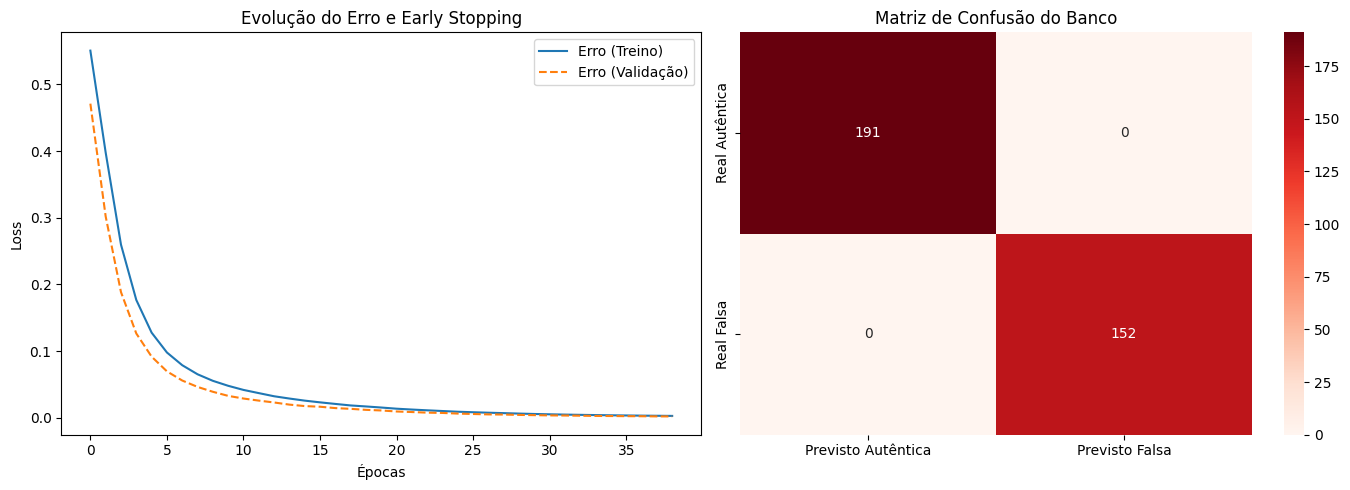

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(historico.history['loss'], label='Erro (Treino)')
ax1.plot(historico.history['val_loss'], label='Erro (Validação)', linestyle='--')
ax1.set_title("Evolução do Erro e Early Stopping")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend()

matriz = confusion_matrix(Y_test, previsoes_finais)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Previsto Autêntica', 'Previsto Falsa'],
            yticklabels=['Real Autêntica', 'Real Falsa'])
ax2.set_title("Matriz de Confusão do Banco")
plt.tight_layout()
plt.show()

In [114]:
loss, acuracia = modelo_banco.evaluate(X_test, Y_test, batch_size=12)

print(f"Acurácia no teste: {acuracia:.4f}")
print(loss)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8222 - loss: 1.6432
Acurácia no teste: 0.8222
1.6431877613067627
